In [1]:
# Imports
import json
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

print("Libraries loaded!")

Libraries loaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Load Data
with open("../data/clean_msmarco.json", "r") as f:
    data = json.load(f)

with open("../data/bm25_results.json", "r") as f:
    bm25_results = json.load(f)

print(f"Loaded {len(data)} queries and {len(bm25_results)} BM25 results!")

Loaded 4851 queries and 4851 BM25 results!


In [3]:
# Lexical Features
def get_lexical_features(query, passage):
    q_tokens = set(query.lower().split())
    p_tokens = set(passage.lower().split())
    q_list = query.lower().split()
    p_list = passage.lower().split()
    
    # Overlap ratio
    overlap = len(q_tokens & p_tokens) / len(q_tokens) if q_tokens else 0
    
    # Exact match count
    exact = sum(1 for t in q_list if t in p_tokens)
    
    # Bigram overlap
    q_bigrams = set(zip(q_list[:-1], q_list[1:]))
    p_bigrams = set(zip(p_list[:-1], p_list[1:]))
    bigram = len(q_bigrams & p_bigrams) / len(q_bigrams) if q_bigrams else 0
    
    # Jaccard similarity
    jaccard = len(q_tokens & p_tokens) / len(q_tokens | p_tokens) if q_tokens | p_tokens else 0
    
    # Dice coefficient
    dice = 2*len(q_tokens & p_tokens) / (len(q_tokens) + len(p_tokens)) if q_tokens and p_tokens else 0
    
    return [overlap, exact, bigram, jaccard, dice]

print("Lexical features defined!")

Lexical features defined!


In [4]:
# Statistical and Positional Features
def get_stat_positional_features(query, passage):
    q_tokens = query.lower().split()
    p_tokens = passage.lower().split()
    
    # Statistical
    q_len = len(q_tokens)
    p_len = len(p_tokens)
    tf_variance = np.var([p_tokens.count(t) for t in q_tokens]) if q_tokens else 0
    unique_matches = len(set(q_tokens) & set(p_tokens))
    
    # Positional
    positions = [i for i, t in enumerate(p_tokens) if t in set(q_tokens)]
    first_pos = positions[0]/p_len if positions else 1.0
    last_pos = positions[-1]/p_len if positions else 1.0
    avg_pos = np.mean(positions)/p_len if positions else 1.0
    coverage = len(positions)/p_len if p_len > 0 else 0
    
    return [q_len, p_len, tf_variance, unique_matches, first_pos, last_pos, avg_pos, coverage]

print("Statistical + Positional features defined!")

Statistical + Positional features defined!


In [8]:
# Semantic Features
# Precompute IDF
from collections import Counter

doc_freq = Counter()
for item in data:
    for passage in item['passages']:
        for term in set(passage.lower().split()):
            doc_freq[term] += 1

N = len(data)

def get_semantic_features(query, passage):
    q_tokens = query.lower().split()
    p_tokens = passage.lower().split()
    
    stop_ratio = len([t for t in p_tokens if t in STOPWORDS]) / len(p_tokens) if p_tokens else 0
    unique_q_in_p = len(set(q_tokens) & set(p_tokens)) / len(set(q_tokens)) if q_tokens else 0
    sent_count = passage.count('.') + passage.count('?') + passage.count('!')
    q_chars = set([query[i:i+3] for i in range(len(query)-2)])
    p_chars = set([passage[i:i+3] for i in range(len(passage)-2)])
    char_sim = len(q_chars & p_chars) / len(q_chars | p_chars) if q_chars | p_chars else 0
    idf_sum = sum(np.log(N/(1 + doc_freq.get(t, 0))) for t in q_tokens)
    
    return [stop_ratio, unique_q_in_p, sent_count, char_sim, idf_sum]

print("Semantic features redefined!")

Semantic features redefined!


In [9]:
# Build Full Feature Matrix
feature_matrix = []
labels_list = []

for idx, item in enumerate(tqdm(data)):
    query = item['query']
    scores = bm25_results[idx]['scores']
    
    for i, passage in enumerate(item['passages']):
        bm25_score = scores[i] if i < len(scores) else 0
        
        features = (
            [bm25_score] +
            get_lexical_features(query, passage) +
            get_stat_positional_features(query, passage) +
            get_semantic_features(query, passage)
        )
        feature_matrix.append(features)
        labels_list.append(item['labels'][i])

feature_matrix = np.array(feature_matrix)
labels_list = np.array(labels_list)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Labels shape: {labels_list.shape}")

100%|█████████████████████████████████████████████████████████████████████████████| 4851/4851 [00:26<00:00, 184.33it/s]


Feature matrix shape: (39962, 19)
Labels shape: (39962,)


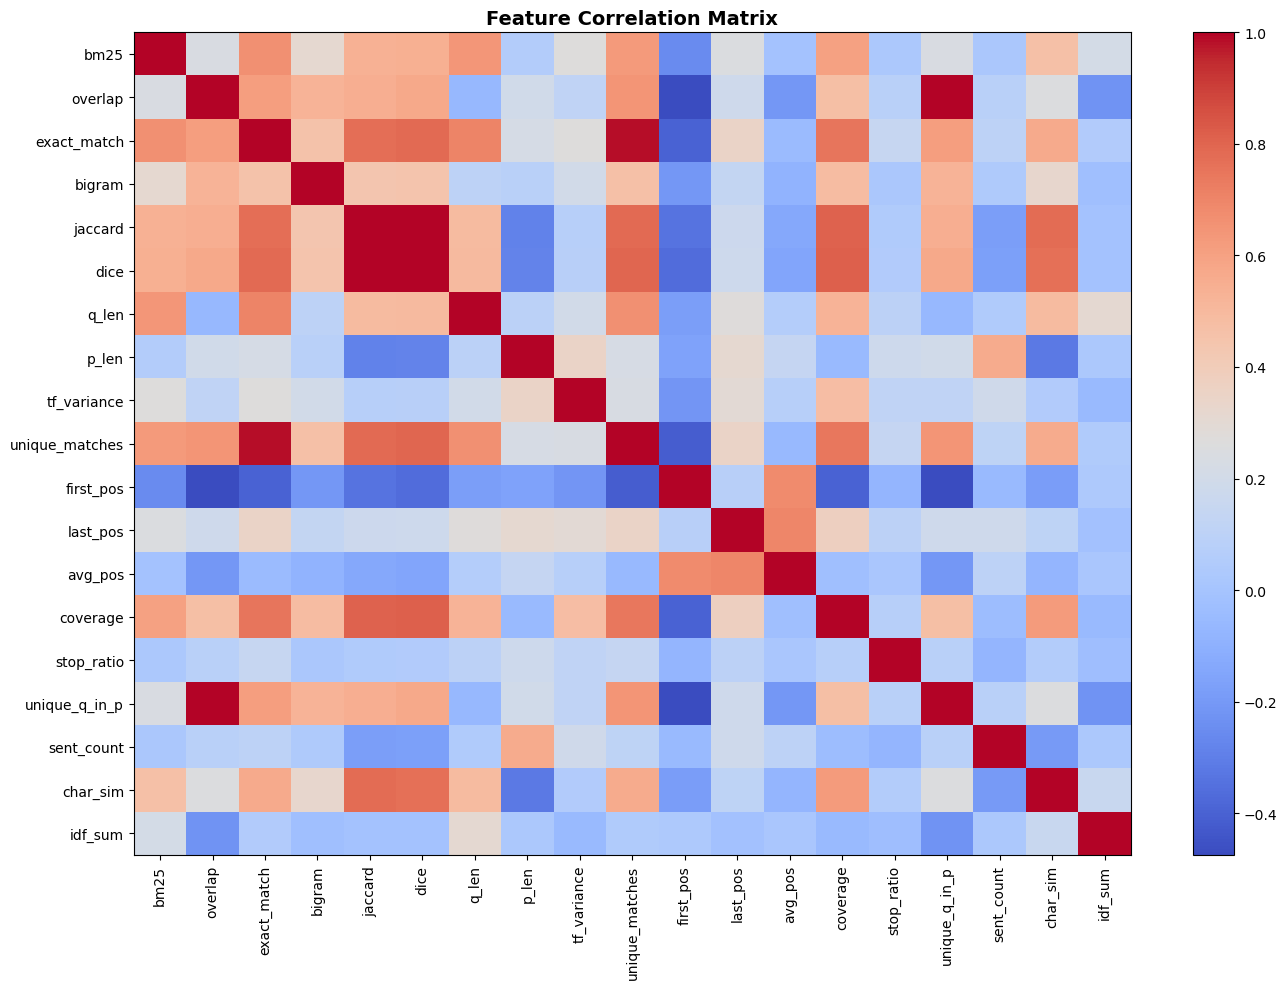

Heatmap saved!


In [10]:
# Correlation Heatmap
import matplotlib.pyplot as plt

feature_names = ['bm25', 'overlap', 'exact_match', 'bigram', 'jaccard', 'dice',
                 'q_len', 'p_len', 'tf_variance', 'unique_matches', 
                 'first_pos', 'last_pos', 'avg_pos', 'coverage',
                 'stop_ratio', 'unique_q_in_p', 'sent_count', 'char_sim', 'idf_sum']

df = pd.DataFrame(feature_matrix, columns=feature_names)
corr = df.corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/feature_correlation.png", dpi=150)
plt.show()
print("Heatmap saved!")

In [12]:
# LSA Semantic Similarity
from sklearn.pipeline import Pipeline

lsa = Pipeline([('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
                ('svd', TruncatedSVD(n_components=100, random_state=42))])

lsa.fit([" ".join(item['passages']) for item in data])

lsa_scores = np.concatenate([
    cosine_similarity(lsa.transform([item['query']]), lsa.transform(item['passages']))[0]
    for item in tqdm(data)
])

feature_matrix = np.column_stack([feature_matrix, lsa_scores])
feature_names.append('lsa_sim')
print(f"Updated shape: {feature_matrix.shape}")

100%|██████████████████████████████████████████████████████████████████████████████| 4851/4851 [00:56<00:00, 85.77it/s]

Updated shape: (39962, 20)


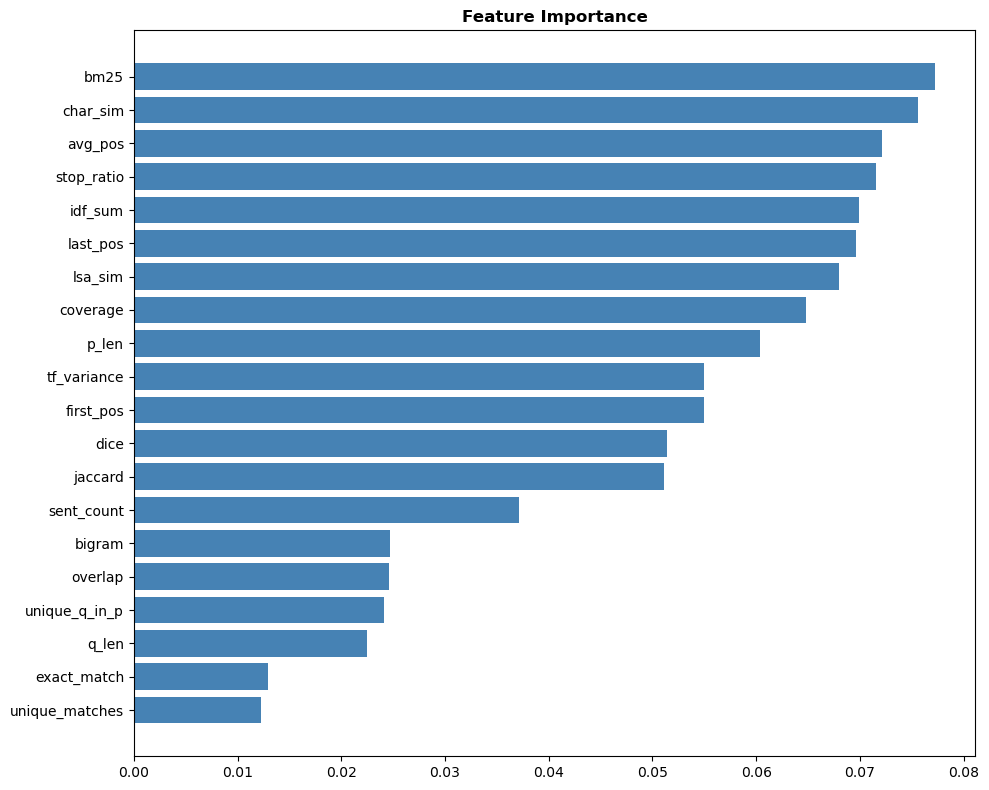

In [13]:
# Feature Importance
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(feature_matrix, labels_list)

imp = pd.DataFrame({'feature': feature_names, 'importance': rf.feature_importances_}).sort_values('importance')
plt.figure(figsize=(10, 8))
plt.barh(imp['feature'], imp['importance'], color='steelblue')
plt.title("Feature Importance", fontweight='bold')
plt.tight_layout()
plt.savefig("../data/feature_importance.png", dpi=150)
plt.show()

In [14]:
# TF-IDF Cosine Similarity
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
tfidf.fit([p for item in data for p in item['passages']])

tfidf_scores = np.concatenate([
    cosine_similarity(tfidf.transform([item['query']]), tfidf.transform(item['passages']))[0]
    for item in tqdm(data)
])

feature_matrix = np.column_stack([feature_matrix, tfidf_scores])
feature_names.append('tfidf_cosine')
print(f"Final shape: {feature_matrix.shape}")

100%|█████████████████████████████████████████████████████████████████████████████| 4851/4851 [00:20<00:00, 241.32it/s]

Final shape: (39962, 21)


In [15]:
# Add Normalized BM25 and Doc Frequency
bm25_scores = feature_matrix[:, 0]
normalized_bm25 = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min())

doc_freq_scores = np.array([
    np.mean([doc_freq.get(t, 0)/len(data) for t in item['query'].lower().split()])
    for item in data
    for _ in item['passages']
])

feature_matrix = np.column_stack([feature_matrix, normalized_bm25, doc_freq_scores])
feature_names.extend(['normalized_bm25', 'doc_freq'])
print(f"Final shape: {feature_matrix.shape}")
print(f"Total features: {len(feature_names)}")

Final shape: (39962, 23)
Total features: 23


In [16]:
# Save Feature Matrix
np.save("../data/feature_matrix.npy", feature_matrix)
np.save("../data/labels.npy", labels_list)
pd.DataFrame(feature_matrix, columns=feature_names).to_csv("../data/feature_matrix.csv", index=False)
json.dump(feature_names, open("../data/feature_names.json", "w"))

print(f"Saved! Shape: {feature_matrix.shape}")
print(f"Features: {feature_names}")

Saved! Shape: (39962, 23)
Features: ['bm25', 'overlap', 'exact_match', 'bigram', 'jaccard', 'dice', 'q_len', 'p_len', 'tf_variance', 'unique_matches', 'first_pos', 'last_pos', 'avg_pos', 'coverage', 'stop_ratio', 'unique_q_in_p', 'sent_count', 'char_sim', 'idf_sum', 'lsa_sim', 'tfidf_cosine', 'normalized_bm25', 'doc_freq']
